# Data Analysis

Explore the restaurant food waste dataset and visualize key patterns.

### Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

### Load Dataset

In [3]:
df = pd.read_csv("../data/processed/restaurant_food_waste_final_dataset.csv")

df.head()

,date,year,month,week,day_of_week,restaurant_id,city_code,region_code,center_type,op_area,...,is_weekend,is_holiday,special_event,temperature_c,precipitation_mm,estimated_customers,num_orders,food_sold_kg,food_prepared_kg,food_waste_kg
0,2018-01-01,2018,1,1,Monday,10,590,56,TYPE_B,6.3,...,0,1,1,18.5,1.0,1930,3016,898.56,986.32,87.76
1,2018-01-01,2018,1,1,Monday,11,679,56,TYPE_A,3.7,...,0,1,1,18.5,1.0,1514,2100,605.61,665.45,59.84
2,2018-01-01,2018,1,1,Monday,13,590,56,TYPE_B,6.7,...,0,1,1,18.5,1.0,2347,3678,1072.00,1177.65,105.65
3,2018-01-01,2018,1,1,Monday,14,654,56,TYPE_C,2.7,...,0,1,1,18.5,1.0,867,1107,325.74,358.36,32.62
4,2018-01-01,2018,1,1,Monday,17,517,56,TYPE_A,3.2,...,0,1,1,18.5,1.0,711,982,283.79,311.81,28.02


### Dataset Shape

In [4]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(77980, 27)


### Dataset Columns

In [5]:
print(df.columns)

Index(['date', 'year', 'month', 'week', 'day_of_week', 'restaurant_id',
       'city_code', 'region_code', 'center_type', 'op_area', 'unique_meals',
       'dominant_category', 'dominant_cuisine', 'avg_checkout_price',
       'avg_base_price', 'emailer_promo_rate', 'homepage_feature_rate',
       'is_weekend', 'is_holiday', 'special_event', 'temperature_c',
       'precipitation_mm', 'estimated_customers', 'num_orders', 'food_sold_kg',
       'food_prepared_kg', 'food_waste_kg'],
      dtype='str')


### Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77980 entries, 0 to 77979
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   77980 non-null  str    
 1   year                   77980 non-null  int64  
 2   month                  77980 non-null  int64  
 3   week                   77980 non-null  int64  
 4   day_of_week            77980 non-null  str    
 5   restaurant_id          77980 non-null  int64  
 6   city_code              77980 non-null  int64  
 7   region_code            77980 non-null  int64  
 8   center_type            77980 non-null  str    
 9   op_area                77980 non-null  float64
 10  unique_meals           77980 non-null  int64  
 11  dominant_category      77980 non-null  str    
 12  dominant_cuisine       77980 non-null  str    
 13  avg_checkout_price     77980 non-null  float64
 14  avg_base_price         77980 non-null  float64
 15  emailer_promo

## Statistical Summary

In [7]:
df.describe()

,year,month,week,restaurant_id,city_code,region_code,op_area,unique_meals,avg_checkout_price,avg_base_price,...,is_weekend,is_holiday,special_event,temperature_c,precipitation_mm,estimated_customers,num_orders,food_sold_kg,food_prepared_kg,food_waste_kg
count,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,...,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000,77980.000000
mean,2018.923250,6.157746,73.125673,83.275583,600.632406,56.429533,3.986580,40.982765,271.372642,302.315916,...,0.285714,0.100526,0.234381,25.609379,5.252665,1088.447063,1533.181393,443.774450,477.333875,33.559425
std,0.796056,3.312496,41.818465,45.755706,66.357357,17.977933,1.100286,5.674657,23.294757,25.795252,...,0.451757,0.300702,0.423614,4.868273,4.058024,560.187880,835.645741,239.606618,257.901431,19.350766
min,2018.000000,1.000000,1.000000,10.000000,456.000000,23.000000,0.900000,16.000000,172.189284,190.284485,...,0.000000,0.000000,0.000000,16.600000,1.000000,94.000000,118.000000,32.960000,35.060000,2.100000
25%,2018.000000,3.000000,37.000000,50.000000,553.000000,34.000000,3.500000,38.000000,256.977520,284.719357,...,0.000000,0.000000,0.000000,20.900000,2.300000,691.000000,956.000000,277.897500,298.930000,20.200000
50%,2019.000000,6.000000,73.000000,77.000000,596.000000,56.000000,3.900000,41.000000,271.440617,300.216343,...,0.000000,0.000000,0.000000,26.000000,2.600000,955.000000,1317.000000,383.155000,412.015000,28.670000
75%,2020.000000,9.000000,109.000000,110.000000,651.000000,77.000000,4.400000,45.000000,285.891483,317.390514,...,1.000000,0.000000,0.000000,30.400000,9.000000,1348.000000,1896.000000,548.092500,589.582500,41.730000
max,2020.000000,12.000000,145.000000,186.000000,713.000000,93.000000,7.000000,51.000000,392.899173,470.497395,...,1.000000,1.000000,1.000000,32.700000,13.200000,5817.000000,8150.000000,2843.480000,3067.080000,223.600000


### Missing Value Check

In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

### Missing Value Visualization

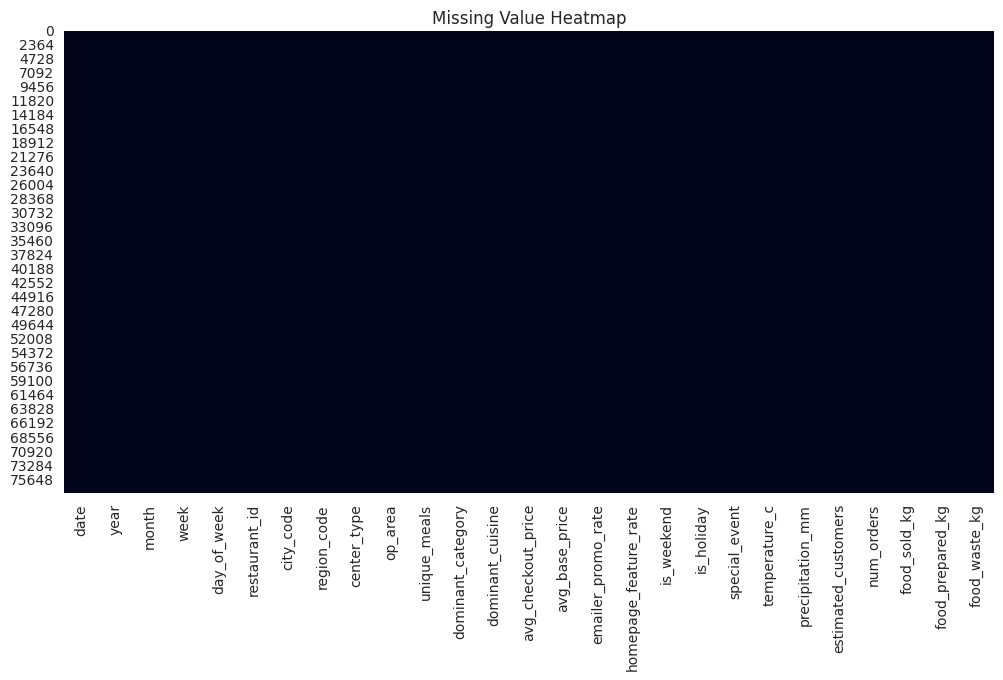

In [9]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Heatmap")

plt.show()

### Duplicate Check

In [10]:
duplicates = df.duplicated().sum()

print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 0


### Food Waste Distribution

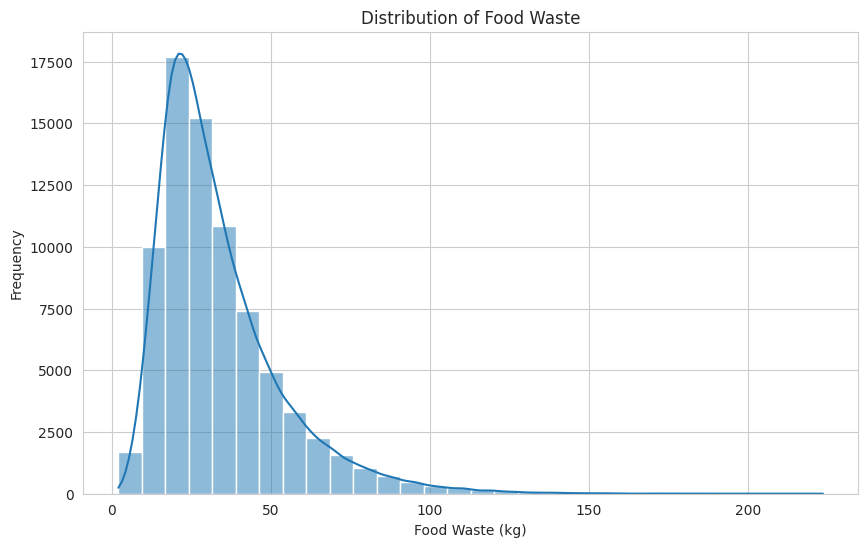

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['food_waste_kg'],
    bins=30,
    kde=True
)

plt.title("Distribution of Food Waste")

plt.xlabel("Food Waste (kg)")
plt.ylabel("Frequency")

plt.show()

In [12]:
numerical_df = df.select_dtypes(
    include=['int64', 'float64']
)

numerical_df.head()

,year,month,week,restaurant_id,city_code,region_code,op_area,unique_meals,avg_checkout_price,avg_base_price,...,is_weekend,is_holiday,special_event,temperature_c,precipitation_mm,estimated_customers,num_orders,food_sold_kg,food_prepared_kg,food_waste_kg
0,2018,1,1,10,590,56,6.3,45,279.143886,300.493569,...,0,1,1,18.5,1.0,1930,3016,898.56,986.32,87.76
1,2018,1,1,11,679,56,3.7,42,259.295134,277.475562,...,0,1,1,18.5,1.0,1514,2100,605.61,665.45,59.84
2,2018,1,1,13,590,56,6.7,45,263.441086,283.023965,...,0,1,1,18.5,1.0,2347,3678,1072.00,1177.65,105.65
3,2018,1,1,14,654,56,2.7,39,271.932432,298.778580,...,0,1,1,18.5,1.0,867,1107,325.74,358.36,32.62
4,2018,1,1,17,517,56,3.2,40,271.664229,295.829375,...,0,1,1,18.5,1.0,711,982,283.79,311.81,28.02


In [13]:
correlation_matrix = numerical_df.corr()

correlation_matrix

,year,month,week,restaurant_id,city_code,region_code,op_area,unique_meals,avg_checkout_price,avg_base_price,...,is_weekend,is_holiday,special_event,temperature_c,precipitation_mm,estimated_customers,num_orders,food_sold_kg,food_prepared_kg,food_waste_kg
year,1.000000,-0.154090,9.399466e-01,-3.364288e-03,5.231506e-04,4.127054e-03,-9.124228e-04,2.616744e-01,3.288387e-01,2.841897e-01,...,2.353521e-03,-0.065967,-0.031382,0.126566,0.044558,0.027360,0.026584,0.017485,0.017848,0.021371
month,-0.154090,1.000000,1.910225e-01,-1.584318e-03,2.463633e-04,1.943522e-03,-4.296803e-04,6.903841e-02,5.675939e-02,-1.516367e-02,...,9.481688e-03,0.142964,0.046589,-0.031915,0.425531,-0.002958,-0.002503,-0.006988,-0.000546,0.079258
week,0.939947,0.191022,1.000000e+00,-3.893238e-03,6.054029e-04,4.775929e-03,-1.055878e-03,2.837675e-01,3.457144e-01,2.761283e-01,...,9.236474e-16,-0.017046,-0.018510,0.114069,0.190663,0.025245,0.024685,0.014131,0.016659,0.047052
restaurant_id,-0.003364,-0.001584,-3.893238e-03,1.000000e+00,6.693741e-02,-1.302426e-02,-1.124376e-01,-1.846413e-01,1.367139e-02,-1.665199e-02,...,-8.342983e-17,-0.000143,-0.010530,-0.006801,0.025315,-0.186872,-0.194727,-0.187227,-0.187075,-0.174982
city_code,0.000523,0.000246,6.054029e-04,6.693741e-02,1.000000e+00,3.000633e-02,1.268111e-01,1.002385e-01,-4.726164e-02,-4.686295e-03,...,3.600881e-16,0.000022,0.015204,-0.008114,-0.016452,0.152824,0.140569,0.145471,0.145512,0.138077
region_code,0.004127,0.001944,4.775929e-03,-1.302426e-02,3.000633e-02,1.000000e+00,3.141604e-02,7.433216e-02,-1.153842e-01,-6.682286e-02,...,-6.815760e-18,0.000175,0.006303,0.055169,-0.122680,0.111252,0.099847,0.105890,0.105816,0.099131
op_area,-0.000912,-0.000430,-1.055878e-03,-1.124376e-01,1.268111e-01,3.141604e-02,1.000000e+00,6.367633e-01,-2.307306e-01,-2.286283e-01,...,2.403454e-17,-0.000039,0.061853,0.006904,-0.018273,0.610880,0.648850,0.648123,0.648248,0.614430
unique_meals,0.261674,0.069038,2.837675e-01,-1.846413e-01,1.002385e-01,7.433216e-02,6.367633e-01,1.000000e+00,-2.364065e-01,-1.788196e-01,...,7.258450e-16,0.010425,0.060981,0.042537,0.007821,0.664807,0.675894,0.660537,0.661361,0.635476
avg_checkout_price,0.328839,0.056759,3.457144e-01,1.367139e-02,-4.726164e-02,-1.153842e-01,-2.307306e-01,-2.364065e-01,1.000000e+00,7.181630e-01,...,-6.130749e-17,0.004021,-0.050134,0.089562,0.210498,-0.357334,-0.343792,-0.344167,-0.341785,-0.293638
avg_base_price,0.284190,-0.015164,2.761283e-01,-1.665199e-02,-4.686295e-03,-6.682286e-02,-2.286283e-01,-1.788196e-01,7.181630e-01,1.000000e+00,...,2.607014e-16,-0.098549,-0.058315,0.070664,0.166642,-0.149085,-0.154786,-0.135788,-0.134194,-0.107141


### Correlation Heatmap

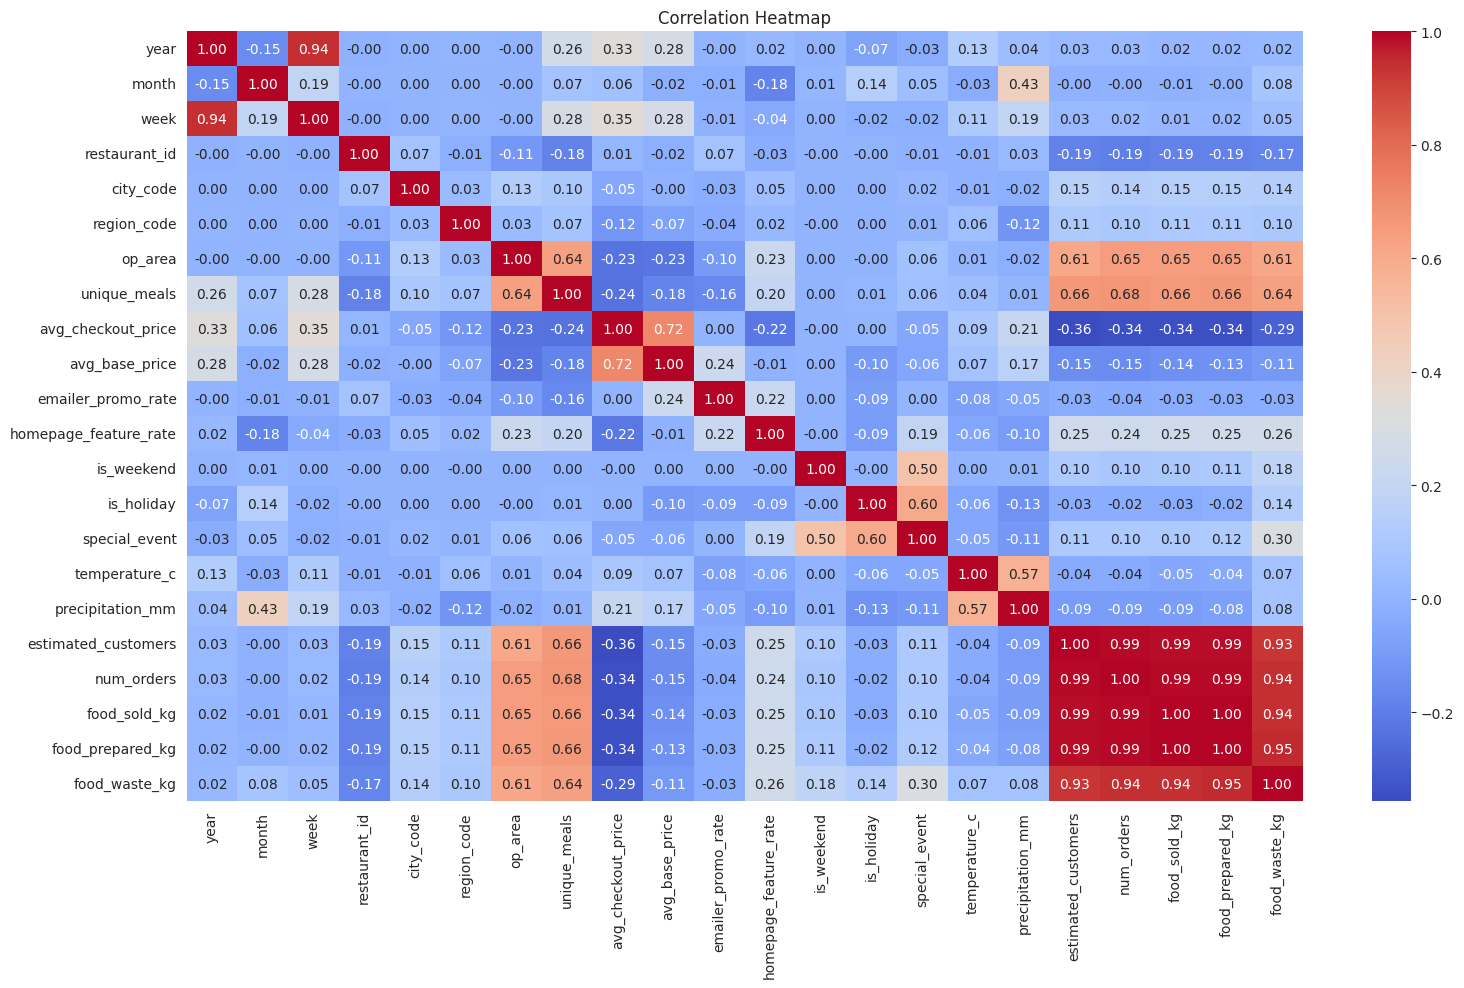

In [14]:
plt.figure(figsize=(18,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Orders vs Food Waste

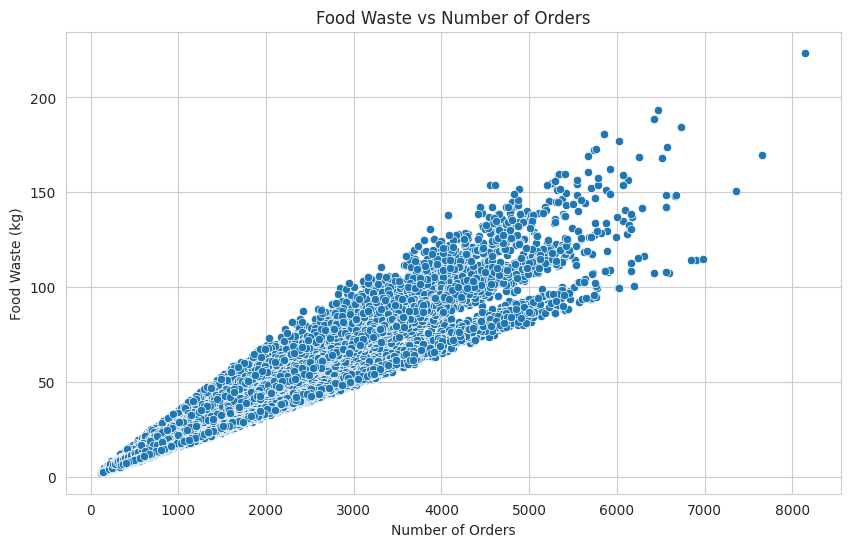

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['num_orders'],
    y=df['food_waste_kg']
)

plt.title("Food Waste vs Number of Orders")

plt.xlabel("Number of Orders")
plt.ylabel("Food Waste (kg)")

plt.show()

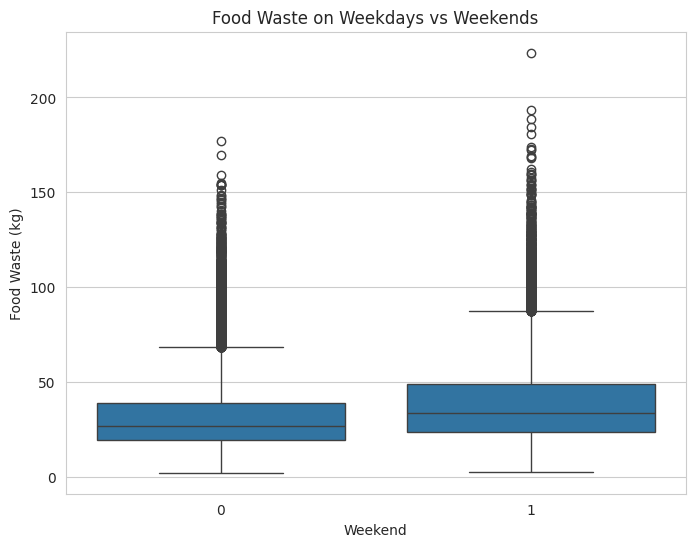

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=df['is_weekend'],
    y=df['food_waste_kg']
)

plt.title("Food Waste on Weekdays vs Weekends")

plt.xlabel("Weekend")
plt.ylabel("Food Waste (kg)")

plt.show()

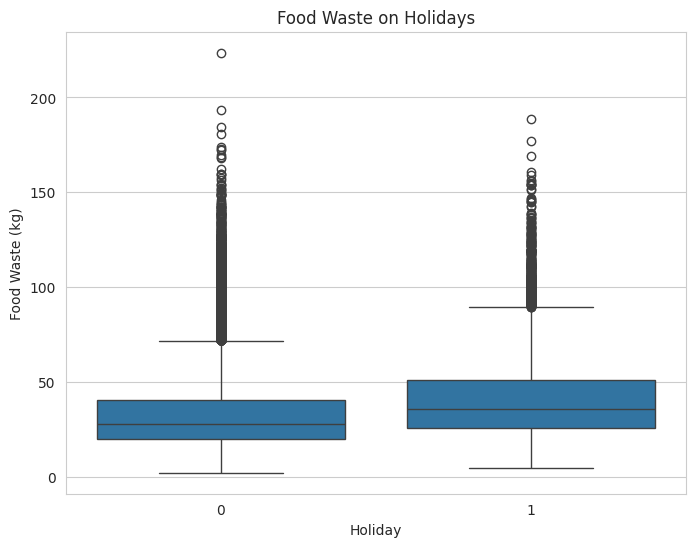

In [17]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=df['is_holiday'],
    y=df['food_waste_kg']
)

plt.title("Food Waste on Holidays")

plt.xlabel("Holiday")
plt.ylabel("Food Waste (kg)")

plt.show()

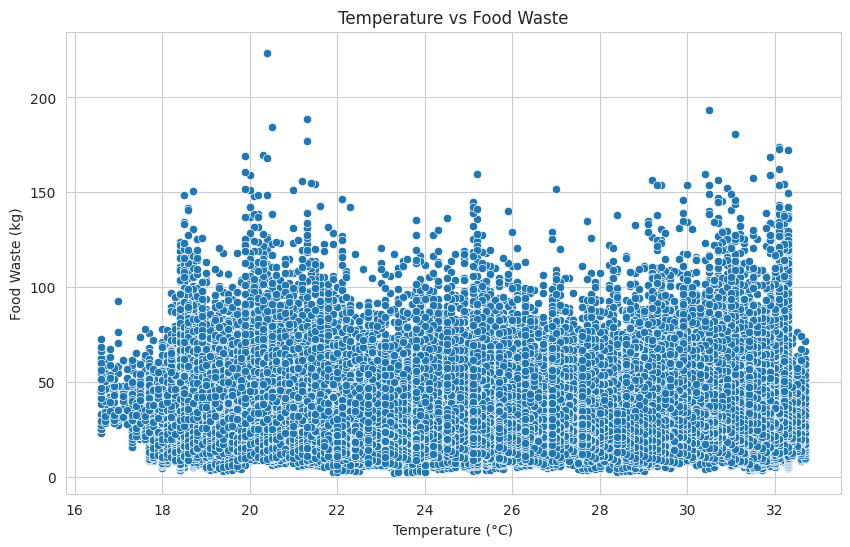

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['temperature_c'],
    y=df['food_waste_kg']
)

plt.title("Temperature vs Food Waste")

plt.xlabel("Temperature (°C)")
plt.ylabel("Food Waste (kg)")

plt.show()

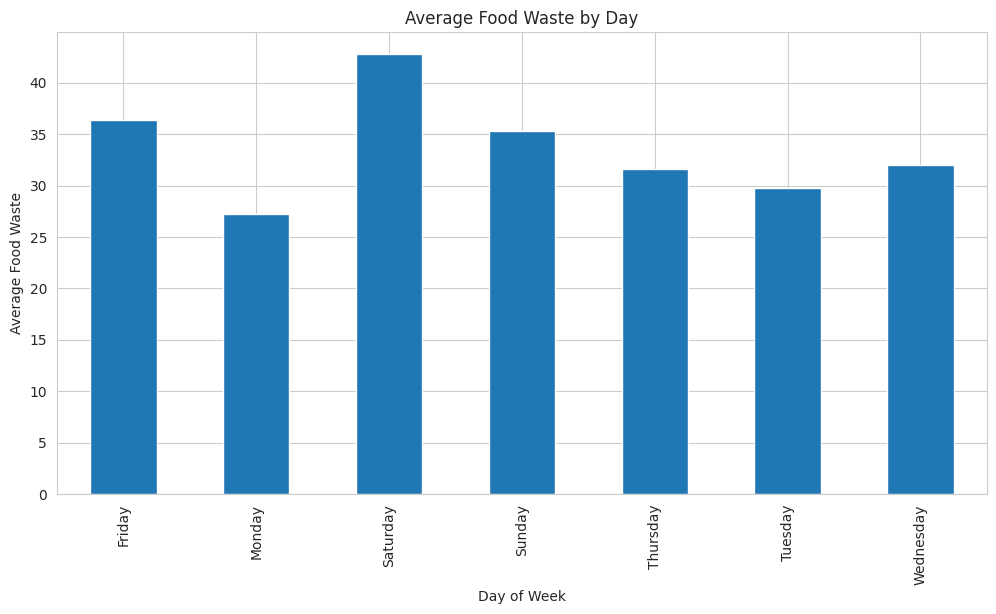

In [19]:
plt.figure(figsize=(12,6))

avg_waste = df.groupby(
    'day_of_week'
)['food_waste_kg'].mean()

avg_waste.plot(kind='bar')

plt.title("Average Food Waste by Day")

plt.xlabel("Day of Week")
plt.ylabel("Average Food Waste")

plt.show()

### Feature Distribution

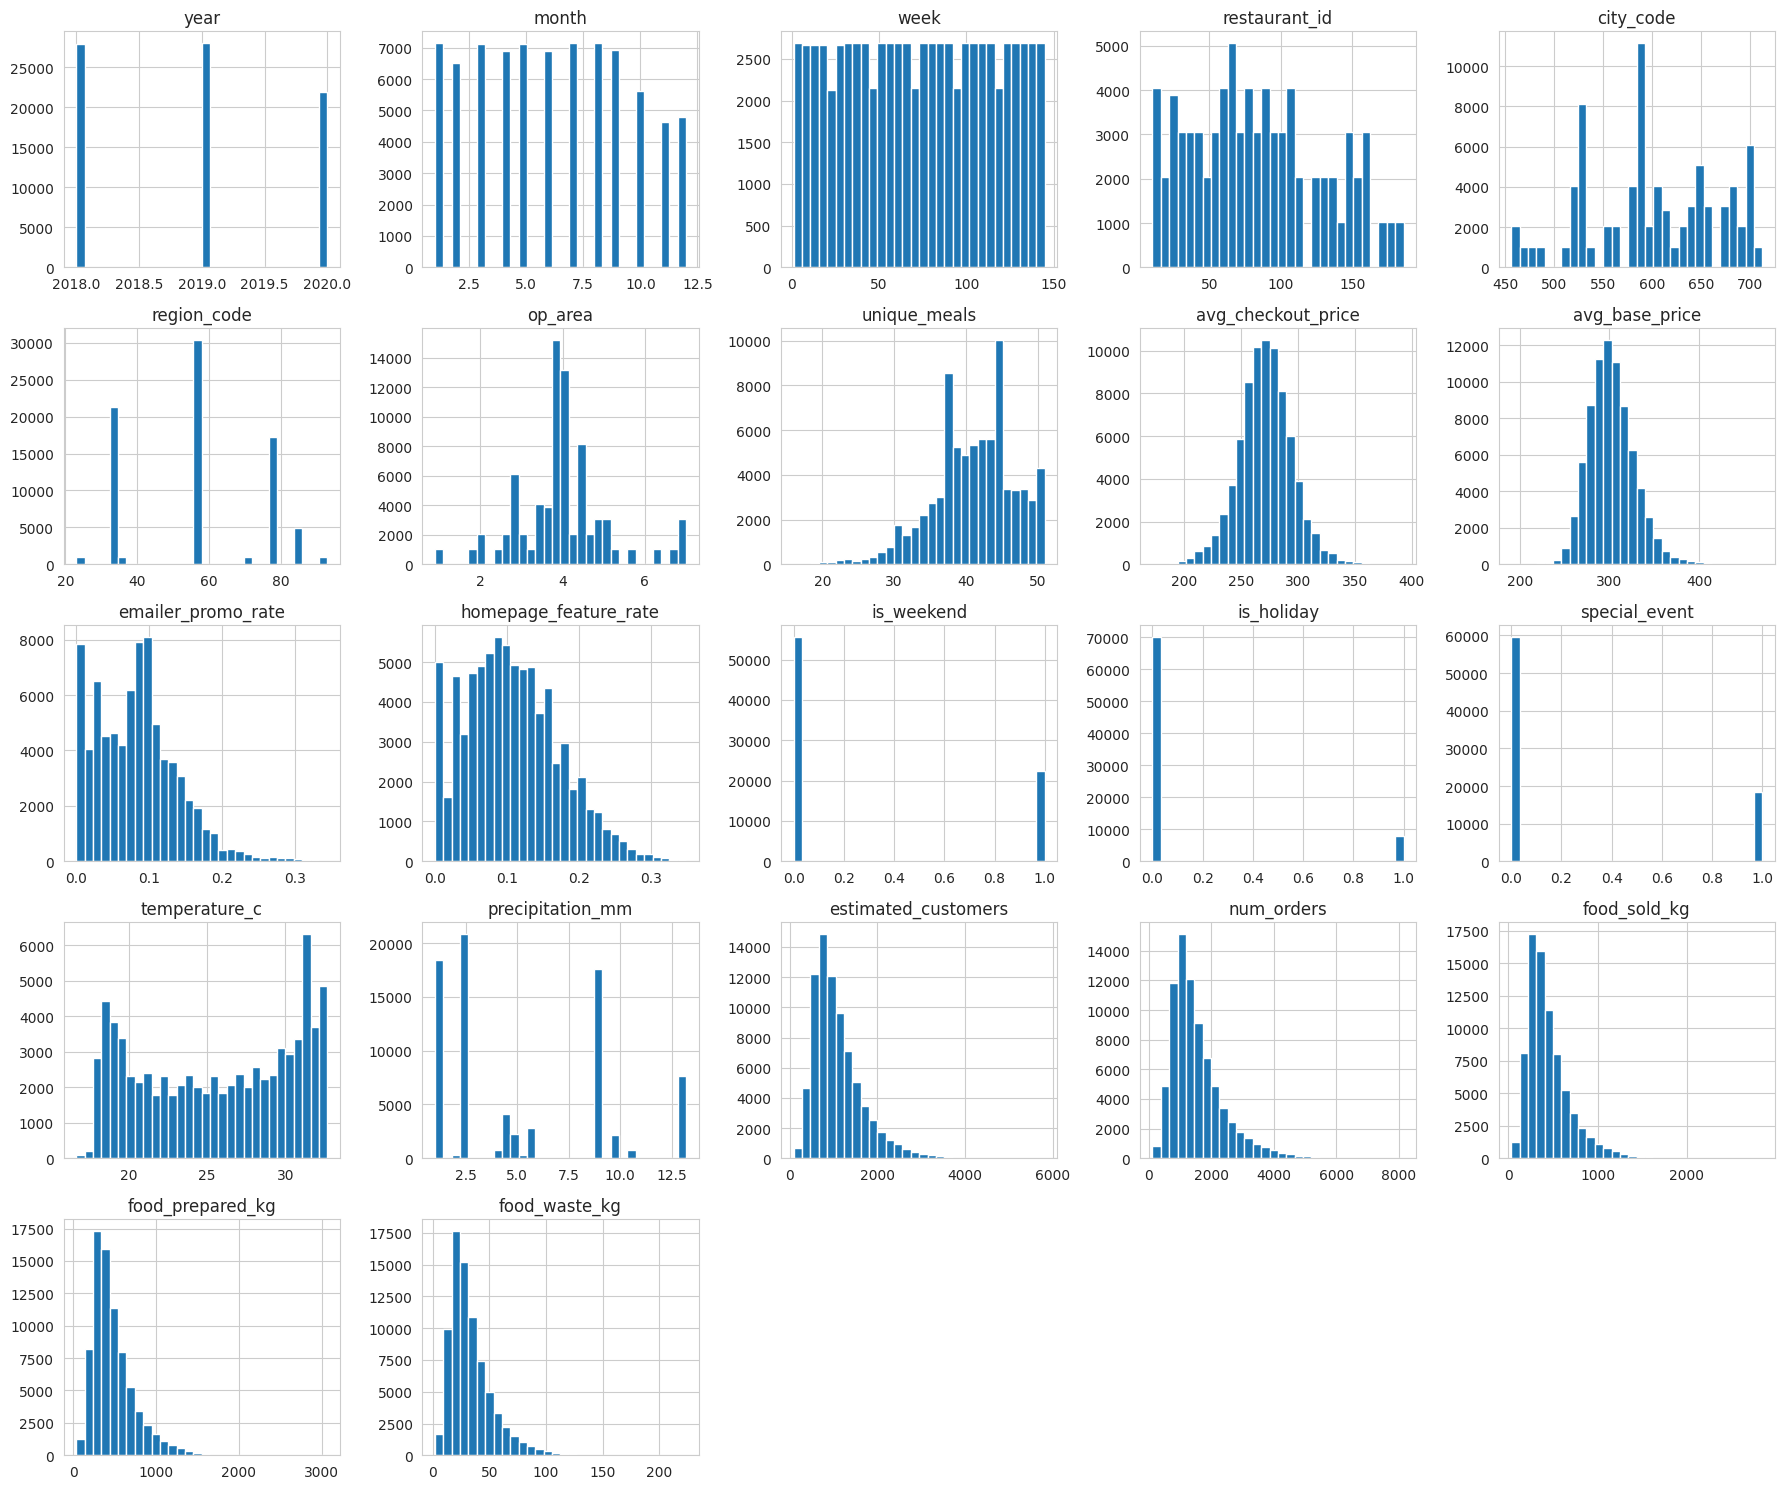

In [20]:
df.hist(
    figsize=(18,15),
    bins=30
)

plt.tight_layout()

plt.show()

### Outlier Detection

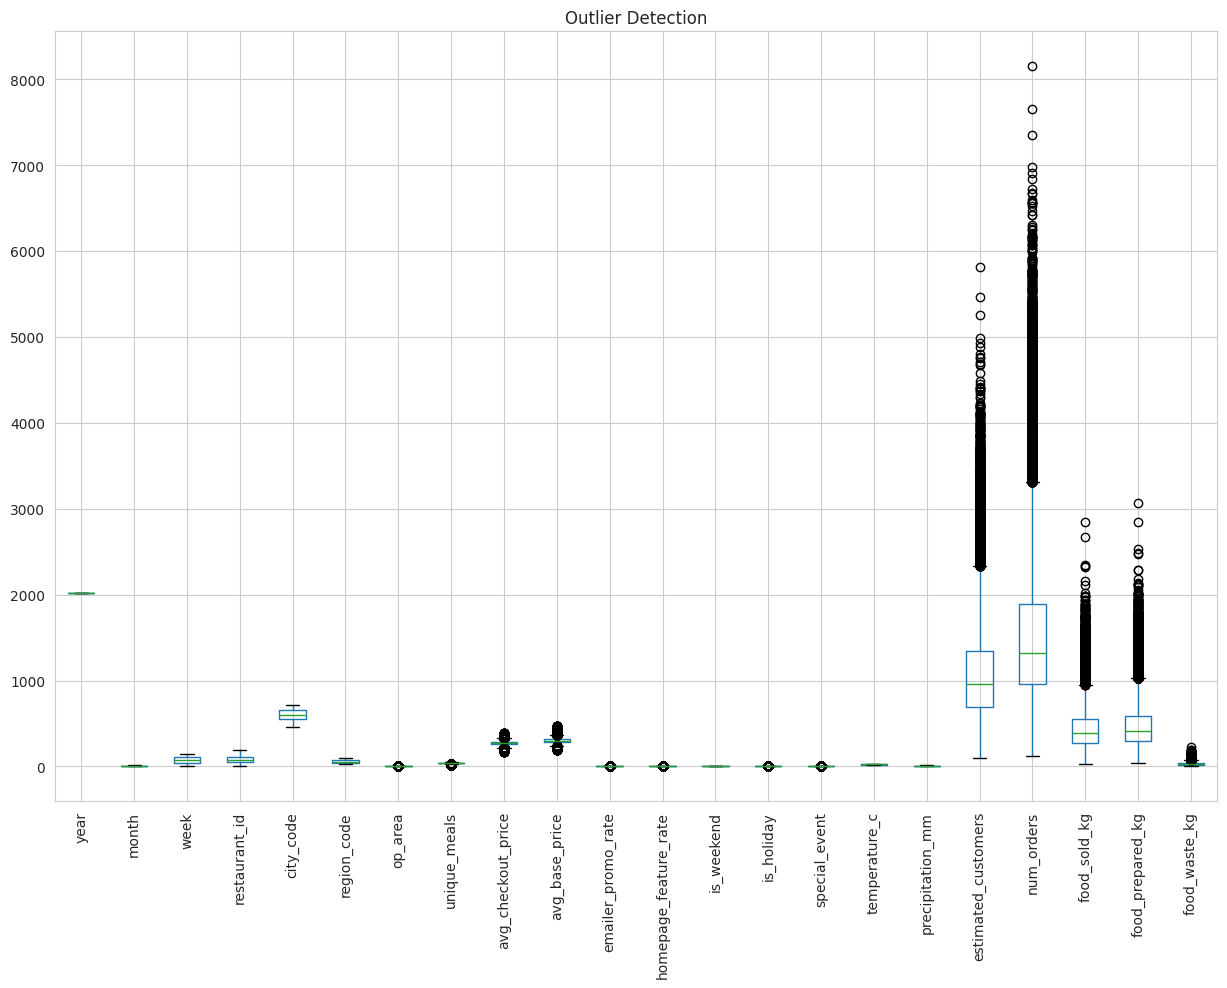

In [21]:
plt.figure(figsize=(15,10))

numerical_df.boxplot(rot=90)

plt.title("Outlier Detection")

plt.show()

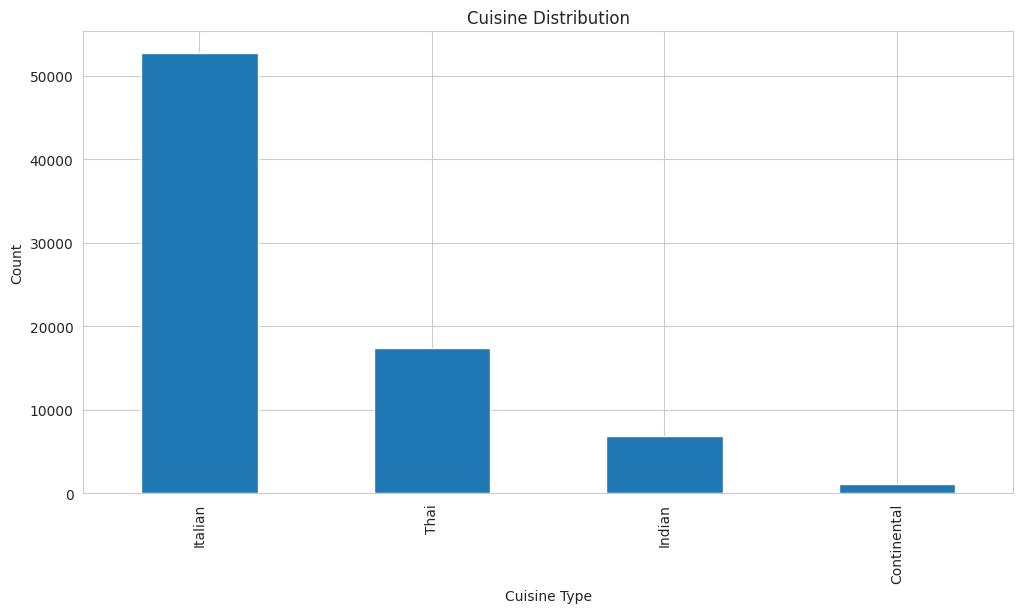

In [22]:
plt.figure(figsize=(12,6))

df['dominant_cuisine'].value_counts().plot(
    kind='bar'
)

plt.title("Cuisine Distribution")

plt.xlabel("Cuisine Type")
plt.ylabel("Count")

plt.show()

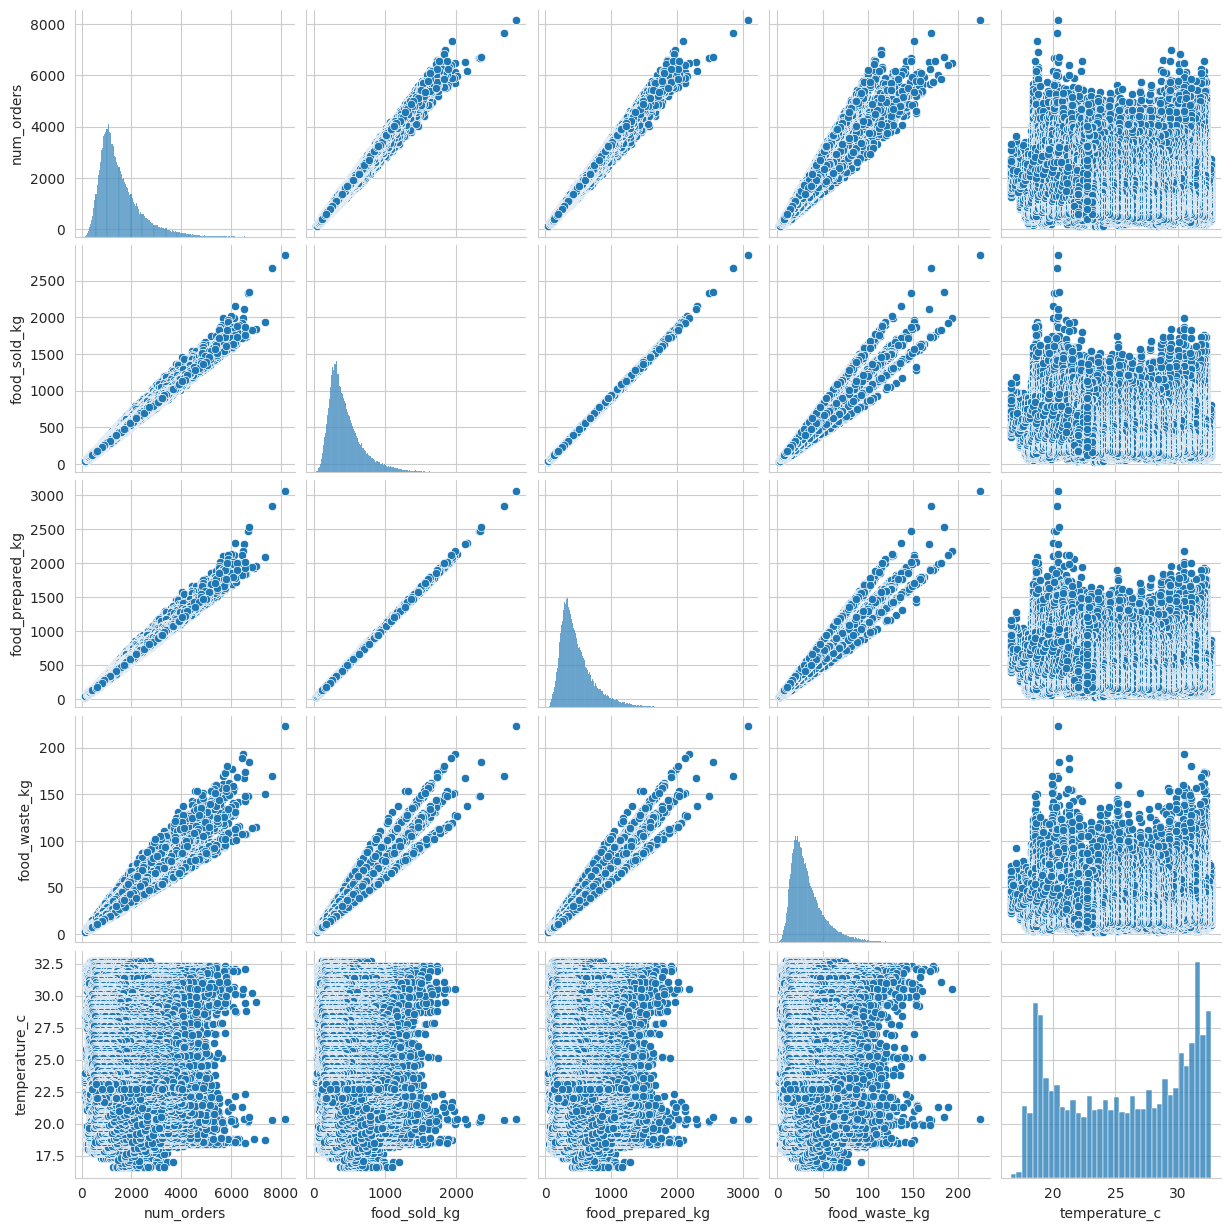

In [23]:
selected_features = [
    'num_orders',
    'food_sold_kg',
    'food_prepared_kg',
    'food_waste_kg',
    'temperature_c'
]

sns.pairplot(
    df[selected_features]
)

plt.show()

In [25]:
encoded_df = df.copy()

label_encoder = LabelEncoder()

categorical_columns = encoded_df.select_dtypes(
    include='object'
).columns

for col in categorical_columns:
    
    encoded_df[col] = label_encoder.fit_transform(
        encoded_df[col].astype(str)
    )

In [26]:
encoded_df.to_csv(
    "../data/processed/eda_processed_dataset.csv",
    index=False
)

print("EDA Dataset Saved Successfully")

EDA Dataset Saved Successfully
